In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

In [3]:
#load the datasets
movies = pd.read_csv('data/movies.csv')
ratings = pd.read_csv('data/ratings.csv')

In [4]:
#preview the data
print("Movies:")
print(movies.head())

print("Ratings:")
print(ratings.head())

#check for missing values
print("\nMissing in Movies:\n", movies.isnull().sum())
print("\nMissing in Ratings:\n", ratings.isnull().sum())

Movies:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
Ratings:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Missing in Movies:
 movieId    0
title      0
genres     0
dtype: int64

Missing in Ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype

In [5]:
print(f"total Movies: {movies['movieId'].nunique()}")
print(f"total Ratings: {ratings['userId'].nunique()}")
print(f"Total Rows in ratings dataframe: {ratings.shape[0]}")
print(f"total columns in ratings dataframe:{ratings.shape[1]}")

print("\nGenre Example:")
print(movies['genres'].value_counts().head(10))


total Movies: 9742
total Ratings: 610
Total Rows in ratings dataframe: 100836
total columns in ratings dataframe:4

Genre Example:
genres
Drama                   1053
Comedy                   946
Comedy|Drama             435
Comedy|Romance           363
Drama|Romance            349
Documentary              339
Comedy|Drama|Romance     276
Drama|Thriller           168
Horror                   167
Horror|Thriller          135
Name: count, dtype: int64


In [6]:
ratings.shape

(100836, 4)

In [7]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
movies.info()
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [9]:
movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [10]:
#merge datasets on 'movieId' (means using movieId column)
df = pd.merge(ratings,movies,on='movieId')
# df = pd.merge(movies ,ratings, on='movieId') this output is having same titles only why ??


#Preview merged data
df.head()


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [11]:
# Names of columns in df
print("\nColumns:",df.columns)


Columns: Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')


In [12]:
#check for duplicate entries
print("\nDuplicates Entries:", df.duplicated().sum())


Duplicates Entries: 0


In [13]:
# Check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


In [14]:
# Basic summary statistics for thr ratings
print("\nSummary Statistics for Ratings:")
print( df['rating'].describe())

# Number of unique genres
print("\nNumber of unique geners:",df['genres'].nunique())

# Mosst frequent genres
print("\nTop 10 most frequent genres:")
print(df['genres'].value_counts().head(10))


Summary Statistics for Ratings:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Number of unique geners: 951

Top 10 most frequent genres:
genres
Comedy                       7196
Drama                        6291
Comedy|Romance               3967
Comedy|Drama|Romance         3000
Comedy|Drama                 2851
Drama|Romance                2838
Action|Adventure|Sci-Fi      2361
Crime|Drama                  2315
Action|Crime|Thriller        1554
Action|Adventure|Thriller    1455
Name: count, dtype: int64


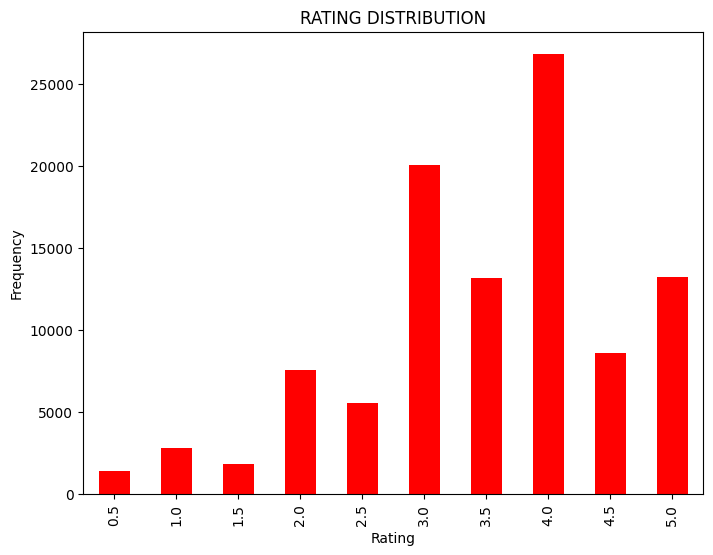

In [15]:
# Plot the distribution of ratings
plt.figure(figsize=(8,6))
df['rating'].value_counts().sort_index().plot(kind='bar', color = 'r')
plt.title('RATING DISTRIBUTION')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [16]:
# Number of ratings per user and per movie
print(f"Average number of ratings per user: {df.groupby('userId').size().mean()}")
print(f"Average number of ratings per movie: {df.groupby('movieId').size().mean()}")

# Most rated movies
top_rated_movies = df.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
print("\nTop 10 Most Rated Movies:")
print(top_rated_movies)


Average number of ratings per user: 165.30491803278687
Average number of ratings per movie: 10.369806663924312

Top 10 Most Rated Movies:
title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64


In [17]:
# Create the user-movie ratings matrix
ratings_matrix = df.pivot_table(index='userId', columns='title', values='rating')

In [18]:
# Preview of user-movie ratings matrix
print(ratings_matrix.head())

title   '71 (2014)  'Hellboy': The Seeds of Creation (2004)  \
userId                                                        
1              NaN                                      NaN   
2              NaN                                      NaN   
3              NaN                                      NaN   
4              NaN                                      NaN   
5              NaN                                      NaN   

title   'Round Midnight (1986)  'Salem's Lot (2004)  \
userId                                                
1                          NaN                  NaN   
2                          NaN                  NaN   
3                          NaN                  NaN   
4                          NaN                  NaN   
5                          NaN                  NaN   

title   'Til There Was You (1997)  'Tis the Season for Love (2015)  \
userId                                                               
1                             Na

In [19]:
# Pick a movie to find similar ones
target_movie = "Forrest Gump (1994)"
movie_ratings = ratings_matrix[target_movie]   # This is a Series not a DataFrame , keep it this way
movie_ratings.head()

userId
1    4.0
2    NaN
3    NaN
4    NaN
5    NaN
Name: Forrest Gump (1994), dtype: float64

In [20]:
# Compute correlation with other movies
similar_movies = ratings_matrix.corrwith(movie_ratings)
# Below it can give runningWarning error ,not a big issue

C:\Users\ADMIN\PycharmProjects\MOVIE RECOMMENDATION SYSTEM\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\ADMIN\PycharmProjects\MOVIE RECOMMENDATION SYSTEM\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\ADMIN\PycharmProjects\MOVIE RECOMMENDATION SYSTEM\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\ADMIN\PycharmProjects\MOVIE RECOMMENDATION SYSTEM\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ADMIN\PycharmProjects\MOVIE RECOMMENDATION SYSTEM\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stdde

In [21]:
# Drop NaNs and create a clean DataFrame
corr_df = pd.DataFrame(similar_movies, columns=['correlation'])
corr_df.dropna(inplace=True)
corr_df = corr_df.reset_index()

In [22]:
# Drop the movie itself
corr_df = corr_df.drop(target_movie, errors = 'ignore')

In [23]:
# Here you can see the correlation score and know how much this movies correlated with "Forest Gump (1994)"
corr_df.head()

,title,correlation
0,"'burbs, The (1989)",0.197712
1,(500) Days of Summer (2009),0.234095
2,*batteries not included (1987),0.892710
3,...And Justice for All (1979),0.928571
4,10 Cent Pistol (2015),-1.000000


In [24]:
ratings_with_titles = ratings.merge(movies, on='movieId')

rating_counts = ratings_with_titles.groupby('title')['rating'].count().reset_index()
rating_counts.columns = ['title', 'num_ratings']
rating_counts.head()

,title,num_ratings
0,'71 (2014),1
1,'Hellboy': The Seeds of Creation (2004),1
2,'Round Midnight (1986),2
3,'Salem's Lot (2004),1
4,'Til There Was You (1997),2


In [25]:
corr_df = corr_df.merge(rating_counts, on='title')

In [26]:
# Only show movies with at least 50 ratings
filtered_corr_df = corr_df[corr_df['num_ratings'] >= 50]

# Sort by correlation
top_similar_movies = filtered_corr_df.sort_values('correlation', ascending=False)

# Show top 10 similar to 'Forrest Gump (1994)'
print(top_similar_movies.head(10))


                          title  correlation  num_ratings
1744        Forrest Gump (1994)     1.000000          329
3261  Mr. Holland's Opus (1995)     0.652144           80
3753          Pocahontas (1995)     0.550118           68
2023    Grumpier Old Men (1995)     0.534682           52
811           Caddyshack (1980)     0.520328           52
1647     Few Good Men, A (1992)     0.517146           57
1650     Field of Dreams (1989)     0.503845           56
545                  Big (1988)     0.492351           91
2228                Hook (1991)     0.484676           53
1952   Good Will Hunting (1997)     0.484042          141


In [27]:
import warnings

# Suppress only the divide/nan RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning) # "RuntimeWarning" - ignore only warnings related to math issues (like divide by zero)

def get_similar_movies(movie_name, min_shared_ratings=5, min_total_ratings=50): # min_shared_ratings=5 = default: at least 5 users must have rated both movies
    # min_total_ratings=50 = default: only consider movies rated by at least 50 people
    target_ratings = ratings_matrix[movie_name]  # get that movie’s column from the user–movie matrix(rating_matrix)

    # Only consider movies with enough overlapping ratings with the target movie
    def has_enough_overlap(x):  # "x" represent a column,ratings for another movie
        common = target_ratings.notna() & x.notna() #  notna() function is used to detect non-missing values in a pandas DataFrame or Series. It returns a boolean mask where True indicates a non-missing value (i.e., not NaN or None), and False indicates a missing value.
        return common.sum() >= min_shared_ratings

    filtered_matrix = ratings_matrix.loc[:,ratings_matrix.apply(has_enough_overlap)]

    # Compute correlation
    similar_scores = filtered_matrix.corrwith(target_ratings)
    # Computes Pearson correlation between each movie and target_ratings.

    # Drop any NaNs or invalid results
    corr_df = pd.DataFrame(similar_scores, columns=['correlation'])
    corr_df.dropna(inplace=True)

    # Join with rating counts
    corr_df = corr_df.join(rating_counts.set_index('title'))

    # Filter by number of total ratings
    result = corr_df[corr_df['num_ratings'] >= min_total_ratings]

    return result.sort_values('correlation', ascending=False)

# Example call:
get_similar_movies("Forrest Gump (1994)").head(10)


,correlation,num_ratings
title,,
Forrest Gump (1994),1.000000,329
Mr. Holland's Opus (1995),0.652144,80
Pocahontas (1995),0.550118,68
Grumpier Old Men (1995),0.534682,52
Caddyshack (1980),0.520328,52
"Few Good Men, A (1992)",0.517146,57
Field of Dreams (1989),0.503845,56
Big (1988),0.492351,91
Hook (1991),0.484676,53


In [28]:
print(get_similar_movies("Good Will Hunting (1997)").head(10))

                              correlation  num_ratings
title                                                 
Good Will Hunting (1997)         1.000000          141
Piano, The (1993)                0.651114           61
Hook (1991)                      0.645268           53
Gone in 60 Seconds (2000)        0.620814           61
Field of Dreams (1989)           0.569194           56
Top Gun (1986)                   0.568358           83
My Cousin Vinny (1992)           0.564910           59
Bourne Supremacy, The (2004)     0.564801           75
Gangs of New York (2002)         0.564555           55
Annie Hall (1977)                0.546169           58


In [29]:
# CONTENT BASED FILTERING

In [30]:
moviess =pd.read_csv('data/tmdb_5000_movies.csv')
credits =pd.read_csv('data/tmdb_5000_credits.csv')

In [31]:
moviess.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [41]:
# Merge both datasets
moviess = moviess.merge(credits, left_on='id', right_on='movie_id')

moviess.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,vote_average,vote_count,movie_id_x,title_y,cast_x,crew_x,movie_id_y,title,cast_y,crew_y
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [48]:
moviess['crew_x'].head()

0    [{"credit_id": "52fe48009251416c750aca23", "de...
1    [{"credit_id": "52fe4232c3a36847f800b579", "de...
2    [{"credit_id": "54805967c3a36829b5002c41", "de...
3    [{"credit_id": "52fe4781c3a36847f81398c3", "de...
4    [{"credit_id": "52fe479ac3a36847f813eaa3", "de...
Name: crew_x, dtype: object